Este notebook utiliza o MediaPipe para a detecção e visualização de pontos de referência (landmarks) do corpo humano (face, pose e mãos) em uma **imagem estática**.

Com esse algoritmo é possível entender como extrair e manipular os landmarks por cada parte do corpo. É importante saber que esse tipo de biblioteca trabalha com identificações numeradas para cada ponto.

Documantação: https://ai.google.dev/edge/mediapipe/solutions/vision/gesture_recognizer?hl=pt-br

**Está sendo instalada a versão do MediaPipe 0.10.14, pois em abril de 2026 identifiquei que a versão atual da biblioteca não utiliza mais o submódulo 'solutions' chamado na célula 4. Recomando atualizar o código par aa versão atual da biblioteca.**


Passos:
- Carregamento de Imagem: Carrega uma imagem de do Google Drive ou do dispositivo local.
- Detecção de Landmarks com MediaPipe Holistic: Aplica o modelo Holistic do MediaPipe para identificar automaticamente os pontos chave do rosto, postura corporal e mãos na imagem.
- Visualização Detalhada: Desenha esses pontos de referência diretamente sobre a imagem, mostrando-os de forma combinada e também isoladamente para cada parte do corpo (rosto, pose, mão esquerda, mão direita).
- Extração de Coordenadas: Imprime as coordenadas (x, y, z) e a visibilidade de cada landmark detectado, fornecendo dados numéricos para análise.

**É importante entender e documentar através de testes e leitura da documentação da biblioteca quais informações os parâmetros Z (possivelmente distância da câmera) e visibility agregam, como usá-los para melhorar a detecção e o quão confiáveis são.**




In [1]:
!pip install opencv-python matplotlib
!pip install mediapipe==0.10.14

  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 41.0 MB/s eta 0:00:00
  Attempting uninstall: mediapipe
    Found existing installation: mediapipe 0.10.20
    Uninstalling mediapipe-0.10.20:
      Successfully uninstalled mediapipe-0.10.20


In [3]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import files


In [4]:
# faz upload da foto do computador
# uploaded = files.upload()

# carrega drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(-0.5, 772.5, 1035.5, -0.5)

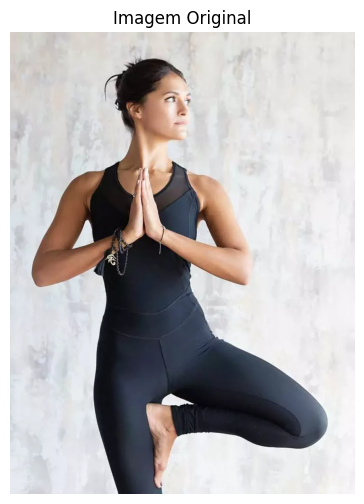

In [5]:
# para utilizar foto carregada do computador
# imagem_path = list(uploaded.keys())[0]

# para imagens carregadas pelo drive
imagem_path = '/content/drive/MyDrive/Colab Notebooks/mediapipe/yoga-iniciante.webp'
img_bgr = cv2.imread(imagem_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Imagem Original")
plt.axis("off")

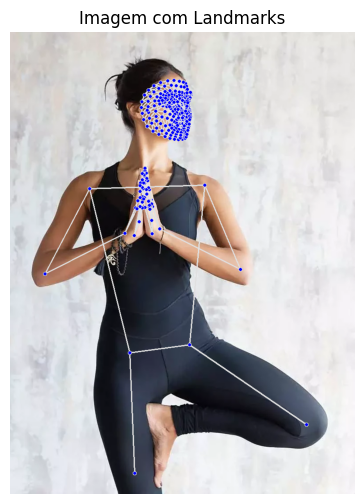

In [6]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

with mp_holistic.Holistic(
    static_image_mode=True,
    model_complexity=1,
    refine_face_landmarks=True
) as holistic:

    results = holistic.process(img_rgb)

    img_landmarks = img_rgb.copy()

    # Desenhar face
    mp_drawing.draw_landmarks(
        img_landmarks,
        results.face_landmarks,
        mp_holistic.FACEMESH_TESSELATION
    )

    # Pose
    mp_drawing.draw_landmarks(
        img_landmarks,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS
    )

    # Mãos
    mp_drawing.draw_landmarks(
        img_landmarks,
        results.left_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )
    mp_drawing.draw_landmarks(
        img_landmarks,
        results.right_hand_landmarks,
        mp_holistic.HAND_CONNECTIONS
    )

    plt.figure(figsize=(6,6))
    plt.imshow(img_landmarks)
    plt.title("Imagem com Landmarks")
    plt.axis("off")


In [7]:
def draw_specific_landmark(img, results, part):
    output = img.copy()

    if part == "face":
        if results.face_landmarks:
            mp_drawing.draw_landmarks(
                output,
                results.face_landmarks,
                mp_holistic.FACEMESH_TESSELATION
            )

    elif part == "left_hand":
        if results.left_hand_landmarks:
            mp_drawing.draw_landmarks(
                output,
                results.left_hand_landmarks,
                mp_holistic.HAND_CONNECTIONS
            )

    elif part == "right_hand":
        if results.right_hand_landmarks:
            mp_drawing.draw_landmarks(
                output,
                results.right_hand_landmarks,
                mp_holistic.HAND_CONNECTIONS
            )

    elif part == "pose":
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(
                output,
                results.pose_landmarks,
                mp_holistic.POSE_CONNECTIONS
            )

    return output


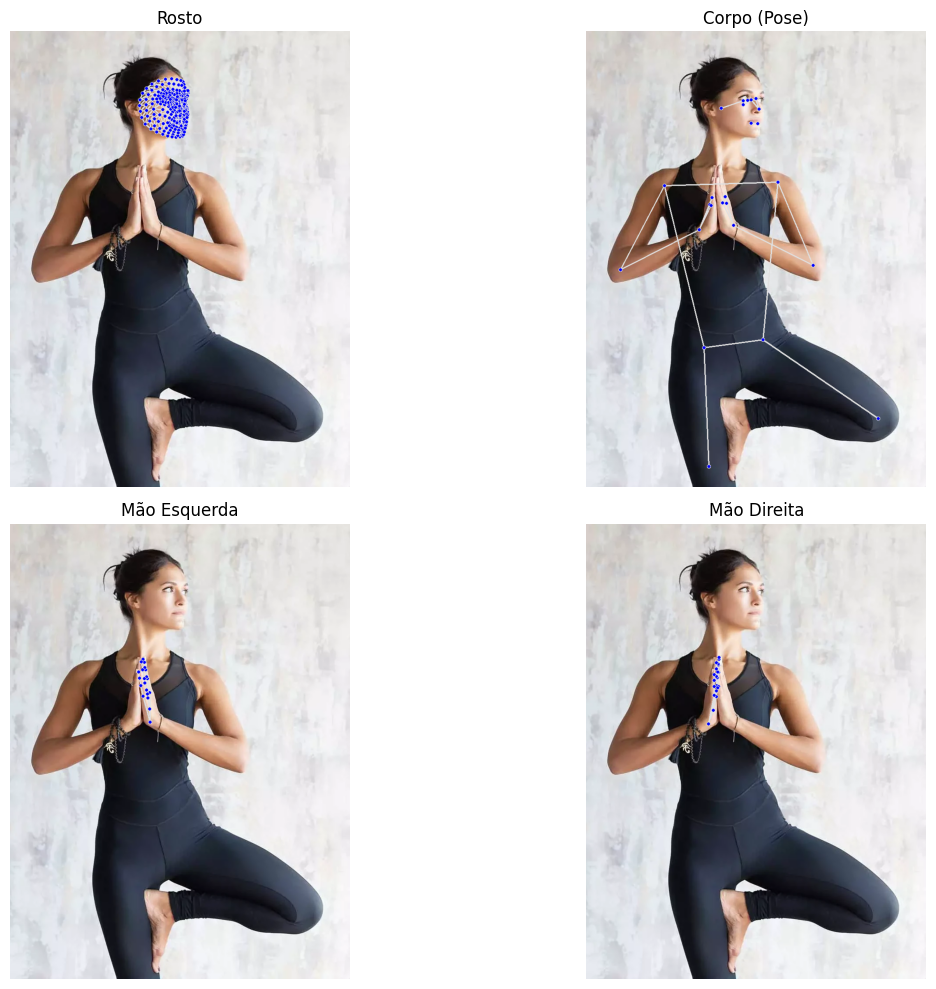

In [8]:
img_face      = draw_specific_landmark(img_rgb, results, "face")
img_left_hand = draw_specific_landmark(img_rgb, results, "left_hand")
img_right_hand = draw_specific_landmark(img_rgb, results, "right_hand")
img_pose      = draw_specific_landmark(img_rgb, results, "pose")

plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.imshow(img_face)
plt.title("Rosto")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(img_pose)
plt.title("Corpo (Pose)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(img_left_hand)
plt.title("Mão Esquerda")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(img_right_hand)
plt.title("Mão Direita")
plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
if results.face_landmarks:
    print("=== FACE LANDMARKS ===")
    for i, lm in enumerate(results.face_landmarks.landmark):
        print(f"Landmark {i}: x={lm.x:.4f}, y={lm.y:.4f}, z={lm.z:.4f}, visibility={lm.visibility:.2f}")
else:
    print("Nenhuma face detectada.")


=== FACE LANDMARKS ===
Landmark 0: x=0.5066, y=0.1911, z=-0.0167, visibility=0.00
Landmark 1: x=0.5175, y=0.1717, z=-0.0229, visibility=0.00
Landmark 2: x=0.5084, y=0.1781, z=-0.0139, visibility=0.00
Landmark 3: x=0.5052, y=0.1582, z=-0.0184, visibility=0.00
Landmark 4: x=0.5175, y=0.1670, z=-0.0234, visibility=0.00
Landmark 5: x=0.5136, y=0.1617, z=-0.0204, visibility=0.00
Landmark 6: x=0.5013, y=0.1487, z=-0.0053, visibility=0.00
Landmark 7: x=0.4569, y=0.1483, z=-0.0214, visibility=0.00
Landmark 8: x=0.4978, y=0.1373, z=0.0002, visibility=0.00
Landmark 9: x=0.4983, y=0.1308, z=0.0010, visibility=0.00
Landmark 10: x=0.4912, y=0.1062, z=0.0122, visibility=0.00
Landmark 11: x=0.5061, y=0.1933, z=-0.0167, visibility=0.00
Landmark 12: x=0.5052, y=0.1953, z=-0.0157, visibility=0.00
Landmark 13: x=0.5040, y=0.1966, z=-0.0140, visibility=0.00
Landmark 14: x=0.5040, y=0.1971, z=-0.0132, visibility=0.00
Landmark 15: x=0.5045, y=0.1985, z=-0.0141, visibility=0.00
Landmark 16: x=0.5046, y=0.200

In [10]:
if results.pose_landmarks:
    print("=== POSE LANDMARKS ===")
    for i, lm in enumerate(results.pose_landmarks.landmark):
        print(f"Landmark {i}: x={lm.x:.4f}, y={lm.y:.4f}, z={lm.z:.4f}, visibility={lm.visibility:.2f}")
else:
    print("Nenhuma pose detectada.")


=== POSE LANDMARKS ===
Landmark 0: x=0.5090, y=0.1717, z=-0.3876, visibility=1.00
Landmark 1: x=0.4981, y=0.1494, z=-0.3240, visibility=1.00
Landmark 2: x=0.4991, y=0.1490, z=-0.3241, visibility=1.00
Landmark 3: x=0.5001, y=0.1485, z=-0.3243, visibility=1.00
Landmark 4: x=0.4856, y=0.1510, z=-0.3702, visibility=1.00
Landmark 5: x=0.4751, y=0.1520, z=-0.3703, visibility=1.00
Landmark 6: x=0.4624, y=0.1528, z=-0.3707, visibility=1.00
Landmark 7: x=0.4622, y=0.1620, z=-0.0202, visibility=1.00
Landmark 8: x=0.3979, y=0.1697, z=-0.2227, visibility=1.00
Landmark 9: x=0.5049, y=0.2031, z=-0.2740, visibility=1.00
Landmark 10: x=0.4859, y=0.2022, z=-0.3332, visibility=1.00
Landmark 11: x=0.5649, y=0.3320, z=0.0630, visibility=1.00
Landmark 12: x=0.2307, y=0.3390, z=-0.1925, visibility=1.00
Landmark 13: x=0.6680, y=0.5142, z=-0.1950, visibility=0.96
Landmark 14: x=0.1015, y=0.5241, z=-0.5170, visibility=0.98
Landmark 15: x=0.4339, y=0.4257, z=-0.6970, visibility=0.96
Landmark 16: x=0.3329, y=0.4

In [11]:
if results.left_hand_landmarks:
    print("=== MÃO ESQUERDA ===")
    for i, lm in enumerate(results.left_hand_landmarks.landmark):
        print(f"Landmark {i}: x={lm.x:.4f}, y={lm.y:.4f}, z={lm.z:.4f}, visibility={lm.visibility:.2f}")
else:
    print("Nenhuma mão esquerda detectada.")


=== MÃO ESQUERDA ===
Landmark 0: x=0.4117, y=0.4368, z=0.0000, visibility=0.00
Landmark 1: x=0.4106, y=0.4080, z=0.0093, visibility=0.00
Landmark 2: x=0.4062, y=0.3836, z=0.0103, visibility=0.00
Landmark 3: x=0.4010, y=0.3660, z=0.0076, visibility=0.00
Landmark 4: x=0.3964, y=0.3508, z=0.0043, visibility=0.00
Landmark 5: x=0.4126, y=0.3712, z=0.0084, visibility=0.00
Landmark 6: x=0.4043, y=0.3410, z=0.0003, visibility=0.00
Landmark 7: x=0.3991, y=0.3218, z=-0.0062, visibility=0.00
Landmark 8: x=0.3950, y=0.3053, z=-0.0108, visibility=0.00
Landmark 9: x=0.4109, y=0.3717, z=-0.0031, visibility=0.00
Landmark 10: x=0.4016, y=0.3374, z=-0.0095, visibility=0.00
Landmark 11: x=0.3962, y=0.3172, z=-0.0148, visibility=0.00
Landmark 12: x=0.3919, y=0.2992, z=-0.0193, visibility=0.00
Landmark 13: x=0.4039, y=0.3747, z=-0.0150, visibility=0.00
Landmark 14: x=0.3951, y=0.3413, z=-0.0193, visibility=0.00
Landmark 15: x=0.3895, y=0.3214, z=-0.0221, visibility=0.00
Landmark 16: x=0.3861, y=0.3048, z=-

In [12]:
if results.right_hand_landmarks:
    print("=== MÃO DIREITA ===")
    for i, lm in enumerate(results.right_hand_landmarks.landmark):
        print(f"Landmark {i}: x={lm.x:.4f}, y={lm.y:.4f}, z={lm.z:.4f}, visibility={lm.visibility:.2f}")
else:
    print("Nenhuma mão direita detectada.")


=== MÃO DIREITA ===
Landmark 0: x=0.3597, y=0.4403, z=-0.0000, visibility=0.00
Landmark 1: x=0.3751, y=0.4108, z=0.0019, visibility=0.00
Landmark 2: x=0.3832, y=0.3807, z=0.0034, visibility=0.00
Landmark 3: x=0.3853, y=0.3568, z=0.0022, visibility=0.00
Landmark 4: x=0.3858, y=0.3394, z=0.0013, visibility=0.00
Landmark 5: x=0.3896, y=0.3585, z=0.0150, visibility=0.00
Landmark 6: x=0.3899, y=0.3275, z=0.0098, visibility=0.00
Landmark 7: x=0.3894, y=0.3116, z=0.0030, visibility=0.00
Landmark 8: x=0.3916, y=0.2986, z=-0.0026, visibility=0.00
Landmark 9: x=0.3876, y=0.3617, z=0.0086, visibility=0.00
Landmark 10: x=0.3880, y=0.3272, z=0.0038, visibility=0.00
Landmark 11: x=0.3884, y=0.3092, z=-0.0033, visibility=0.00
Landmark 12: x=0.3912, y=0.2947, z=-0.0090, visibility=0.00
Landmark 13: x=0.3831, y=0.3683, z=0.0005, visibility=0.00
Landmark 14: x=0.3842, y=0.3363, z=-0.0042, visibility=0.00
Landmark 15: x=0.3834, y=0.3198, z=-0.0083, visibility=0.00
Landmark 16: x=0.3841, y=0.3063, z=-0.01